<a href="https://colab.research.google.com/github/MaheeGamage/TIES4911-DL-for-dev/blob/main/Task-1/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

test

#access file in g drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
with open('/content/drive/MyDrive/Semester 2/Deep Learning for Devs/Assignments/Assignment 1/Datasets/housing.csv', 'r') as f:
  housing_dataset = f.read()

print(housing_dataset)  # To see the output, run the code.

 0.00632  18.00   2.310  0  0.5380  6.5750  65.20  4.0900   1  296.0  15.30 396.90   4.98  24.00
 0.02731   0.00   7.070  0  0.4690  6.4210  78.90  4.9671   2  242.0  17.80 396.90   9.14  21.60
 0.02729   0.00   7.070  0  0.4690  7.1850  61.10  4.9671   2  242.0  17.80 392.83   4.03  34.70
 0.03237   0.00   2.180  0  0.4580  6.9980  45.80  6.0622   3  222.0  18.70 394.63   2.94  33.40
 0.06905   0.00   2.180  0  0.4580  7.1470  54.20  6.0622   3  222.0  18.70 396.90   5.33  36.20
 0.02985   0.00   2.180  0  0.4580  6.4300  58.70  6.0622   3  222.0  18.70 394.12   5.21  28.70
 0.08829  12.50   7.870  0  0.5240  6.0120  66.60  5.5605   5  311.0  15.20 395.60  12.43  22.90
 0.14455  12.50   7.870  0  0.5240  6.1720  96.10  5.9505   5  311.0  15.20 396.90  19.15  27.10
 0.21124  12.50   7.870  0  0.5240  5.6310 100.00  6.0821   5  311.0  15.20 386.63  29.93  16.50
 0.17004  12.50   7.870  0  0.5240  6.0040  85.90  6.5921   5  311.0  15.20 386.71  17.10  18.90
 0.22489  12.50   7.870  0  0.

Sample code

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import matplotlib.pyplot as plt
"%matplotlib inline"
# %matplotlib notebook # use ”%matplotlib inline” instead when do in Google Colab)

# Linear regressor
class SimpleLinearRegression:
    def __init__(self, initializer='random'):
        if initializer=='ones':
            self.var = 1.
        elif initializer=='zeros':
            self.var = 0.
        elif initializer=='random':
            self.var = tf.random.uniform(shape=[], minval=0., maxval=1.)
        self.m = tf.Variable(1., shape=tf.TensorShape(None))
        self.b = tf.Variable(self.var)

    def predict(self, x):
        return tf.reduce_sum(self.m * x, 1) + self.b

    def mse(self, true, predicted):
        return tf.reduce_mean(tf.square(true-predicted))

    def update(self, X, y, learning_rate):
        with tf.GradientTape(persistent=True) as g:
            loss = self.mse(y, self.predict(X))
            print("Loss: ", loss)
            dy_dm = g.gradient(loss, self.m)
            dy_db = g.gradient(loss, self.b)
        self.m.assign_sub(learning_rate * dy_dm)
        self.b.assign_sub(learning_rate * dy_db)

    def train(self, X, y, learning_rate=0.01, epochs=5):
        if len(X.shape)==1:
            X=tf.reshape(X,[X.shape[0],1])
        self.m.assign([self.var]*X.shape[-1])
        for i in range(epochs):
            print("Epoch: ", i)
            self.update(X, y, learning_rate)

In [17]:
dataset[:2,0:13]

array([[6.3200e-03, 1.8000e+01, 2.3100e+00, 0.0000e+00, 5.3800e-01,
        6.5750e+00, 6.5200e+01, 4.0900e+00, 1.0000e+00, 2.9600e+02,
        1.5300e+01, 3.9690e+02, 4.9800e+00],
       [2.7310e-02, 0.0000e+00, 7.0700e+00, 0.0000e+00, 4.6900e-01,
        6.4210e+00, 7.8900e+01, 4.9671e+00, 2.0000e+00, 2.4200e+02,
        1.7800e+01, 3.9690e+02, 9.1400e+00]])

Streaming output truncated to the last 5000 lines.
Epoch:  7500
Loss:  tf.Tensor(0.22698645, shape=(), dtype=float32)
Epoch:  7501
Loss:  tf.Tensor(0.22698645, shape=(), dtype=float32)
Epoch:  7502
Loss:  tf.Tensor(0.22698645, shape=(), dtype=float32)
Epoch:  7503
Loss:  tf.Tensor(0.22698644, shape=(), dtype=float32)
Epoch:  7504
Loss:  tf.Tensor(0.22698644, shape=(), dtype=float32)
Epoch:  7505
Loss:  tf.Tensor(0.22698644, shape=(), dtype=float32)
Epoch:  7506
Loss:  tf.Tensor(0.22698644, shape=(), dtype=float32)
Epoch:  7507
Loss:  tf.Tensor(0.22698644, shape=(), dtype=float32)
Epoch:  7508
Loss:  tf.Tensor(0.22698645, shape=(), dtype=float32)
Epoch:  7509
Loss:  tf.Tensor(0.22698645, shape=(), dtype=float32)
Epoch:  7510
Loss:  tf.Tensor(0.22698644, shape=(), dtype=float32)
Epoch:  7511
Loss:  tf.Tensor(0.22698644, shape=(), dtype=float32)
Epoch:  7512
Loss:  tf.Tensor(0.22698644, shape=(), dtype=float32)
Epoch:  7513
Loss:  tf.Tensor(0.22698644, shape=(), dtype=float32)
Epoch:  751

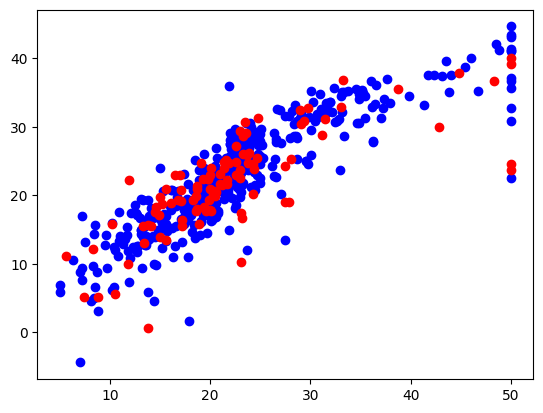

In [16]:
# data preprocessing
housing_dataset_path = "/content/drive/MyDrive/Semester 2/Deep Learning for Devs/Assignments/Assignment 1/Datasets/housing.csv"
dataframe = pd.read_csv(housing_dataset_path, sep='\s+', header=None)
dataset = dataframe.values
X = dataset[:,0:13]
Y = dataset[:,13]

# split the data
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2,
random_state = 0)

# standardize the data
mean_label = y_train.mean(axis=0)
std_label = y_train.std(axis=0)
mean_feat = x_train.mean(axis=0)
std_feat = x_train.std(axis=0)
x_train_norm = (x_train-mean_feat)/std_feat
y_train_norm = (y_train-mean_label)/std_label

# Create and train a regressor
linear_model = SimpleLinearRegression('zeros')
linear_model.train(x_train_norm, y_train_norm, learning_rate=0.01,
epochs=10000)

# standardize
x_test_norm = (x_test-mean_feat)/std_feat

# prediction on test data
test_pred = linear_model.predict(x_test_norm)

# reverse standardization
test_pred *= std_label
test_pred += mean_label

# prediction on train data
train_pred = linear_model.predict(x_train_norm)
# reverse standardization
train_pred *= std_label
train_pred += mean_label
# visualize prediction…
plt.scatter(y_train , train_pred, color = 'blue')
plt.scatter(y_test , test_pred, color = 'red')